In [1]:
import sys
import os
import scMPRAforge as scm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

2025-07-23 21:45:45.809482: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-23 21:45:45.813941: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-07-23 21:45:45.813954: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

cluster=SLURMCluster(
    cores=4,#cores per slurm job
    memory="128G",#memory per slurm job
    processes=16,#dask workers
    job_extra_directives=["-p ycga", 
        f"--job-name=simclust_worker",
        f"--time=4:00:00",
        f"--output=slave_%j.out"]
)

cluster.scale(jobs=4)

client = Client(cluster,
        timeout=f"{5*60}s",   # Client <-> scheduler timeout 
        heartbeat_interval="20s"  # Worker heartbeat interval
    )

In [4]:
#load data
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="ortho_primordial_v2"
primordial=scm.ortho.load(client,path,name)

In [5]:
#create a simulation batch object
batch=scm.simulation_batch(primordial)
batch.describe_primordial()

scMPRAforge: WARNING: Losing params                                    mu        zi     theta
cre_id           cell_type rep_id                        
Lamc1_chr1_12183 reference 2B1    NaN  0.715865  0.075201
                           2B2    NaN  0.952522  0.075201
                           A1     NaN  0.972271  0.075201
                           A2     NaN  0.118319  0.075201
                           B1     NaN  0.315247  0.075201
                           B2     NaN  0.685784  0.075201


In [6]:
batch.simulate_many(client,3)

In [7]:
batch.fit_to_simulations(client)

In [8]:
batch._flatten_all_parameters()

ValueError: cannot reindex on an axis with duplicate labels

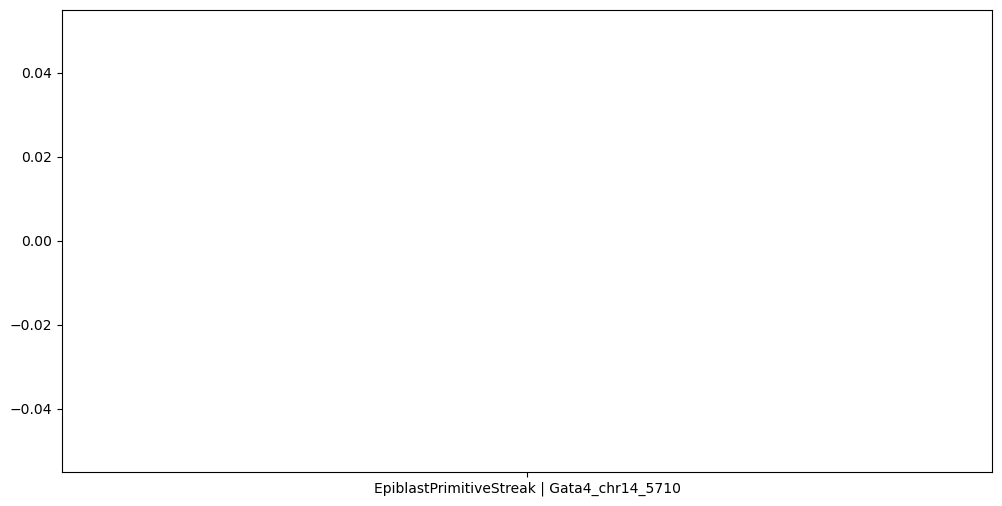

In [9]:
batch.plot_nb_spread()

In [ ]:
cluster.close()